# CNN & fully connected NN (MLP) MNIST

### Importing libraries needed

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np

### Setting up the device (GPU or CPU) and the MNIST data

In [2]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Temporary transform
temp_transform = transforms.ToTensor()

# Load training data (without normalization)
temp_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=temp_transform)
temp_loader  = DataLoader(temp_dataset, batch_size=1000, shuffle=False)

# Compute mean and std
mean = 0.0
std = 0.0
num_batches = 0

for images, _ in temp_loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, -1)
    mean += images.mean(1).sum()
    std += images.std(1).sum()
    num_batches += batch_samples

mean /= num_batches
std /= num_batches

print(f"Calculated Mean: {mean:.4f}, Std: {std:.4f}")

# Apply normalization using computed values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

# Reload datasets with proper normalization
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False, num_workers=2, pin_memory=True)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.23MB/s]


Calculated Mean: 0.1307, Std: 0.3015


### Multi Layer Perceptron (fully connected network version)

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

# instantiate
mlp = MLP().to(device)

### Convolutional Neural Network (CNN)

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

cnn = CNN().to(device)

### Training and evaluation of models functions
- using cross entropy loss criterion
- using ADAM optimizer instead of normal gradient descent

In [5]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    return running_loss / len(loader.dataset)


def eval_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100.0 * correct / total

### Training both models (MLP) and (CNN)
- 5 Epochs each one

In [6]:
import copy

criterion = nn.CrossEntropyLoss()

# Train MLP
mlp_opt = optim.Adam(mlp.parameters(), lr=1e-3)
mlp_hist = {'train_loss': [], 'val_acc': []}
for epoch in range(5):
    loss = train_epoch(mlp, train_loader, mlp_opt, criterion, device)
    acc = eval_model(mlp, test_loader, device)
    mlp_hist['train_loss'].append(loss)
    mlp_hist['val_acc'].append(acc)
    print(f"MLP Epoch {epoch+1} | Loss: {loss:.4f} | Val Acc: {acc:.2f}%")

# Train CNN
cnn_opt = optim.Adam(cnn.parameters(), lr=1e-3)
cnn_hist = {'train_loss': [], 'val_acc': []}
for epoch in range(5):
    loss = train_epoch(cnn, train_loader, cnn_opt, criterion, device)
    acc = eval_model(cnn, test_loader, device)
    cnn_hist['train_loss'].append(loss)
    cnn_hist['val_acc'].append(acc)
    print(f"CNN Epoch {epoch+1} | Loss: {loss:.4f} | Val Acc: {acc:.2f}%")

MLP Epoch 1 | Loss: 0.2265 | Val Acc: 96.65%
MLP Epoch 2 | Loss: 0.0936 | Val Acc: 97.29%
MLP Epoch 3 | Loss: 0.0648 | Val Acc: 97.61%
MLP Epoch 4 | Loss: 0.0489 | Val Acc: 97.35%
MLP Epoch 5 | Loss: 0.0413 | Val Acc: 97.76%
CNN Epoch 1 | Loss: 0.1271 | Val Acc: 98.57%
CNN Epoch 2 | Loss: 0.0420 | Val Acc: 98.92%
CNN Epoch 3 | Loss: 0.0276 | Val Acc: 99.01%
CNN Epoch 4 | Loss: 0.0196 | Val Acc: 99.10%
CNN Epoch 5 | Loss: 0.0157 | Val Acc: 99.01%


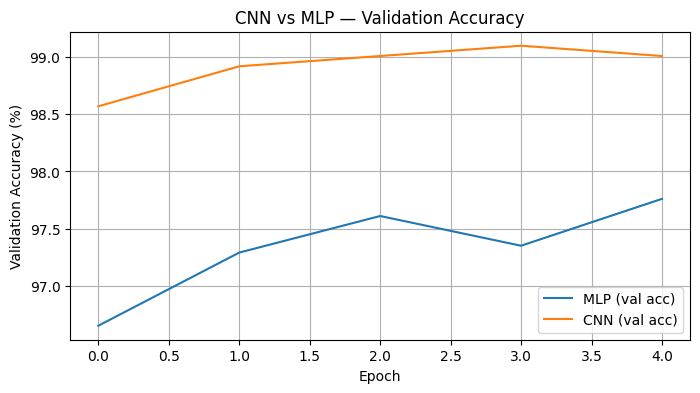

In [7]:
plt.figure(figsize=(8,4))
plt.plot(mlp_hist['val_acc'], label='MLP (val acc)')
plt.plot(cnn_hist['val_acc'], label='CNN (val acc)')
plt.title('CNN vs MLP — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

### Applying dropout regularization on CNN

In [8]:
class CNN_Dropout(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

### Training using different dropout rates
- using 5 epochs


Training with Dropout = 0.1
Epoch 1 Val Acc: 98.67%
Epoch 2 Val Acc: 98.87%
Epoch 3 Val Acc: 99.08%
Epoch 4 Val Acc: 99.03%
Epoch 5 Val Acc: 99.11%

Training with Dropout = 0.3
Epoch 1 Val Acc: 98.55%
Epoch 2 Val Acc: 98.63%
Epoch 3 Val Acc: 99.05%
Epoch 4 Val Acc: 99.10%
Epoch 5 Val Acc: 99.28%

Training with Dropout = 0.5
Epoch 1 Val Acc: 98.31%
Epoch 2 Val Acc: 98.71%
Epoch 3 Val Acc: 98.98%
Epoch 4 Val Acc: 99.09%
Epoch 5 Val Acc: 99.17%

Training with Dropout = 0.7
Epoch 1 Val Acc: 98.19%
Epoch 2 Val Acc: 98.62%
Epoch 3 Val Acc: 99.05%
Epoch 4 Val Acc: 98.99%
Epoch 5 Val Acc: 99.00%

Dropout final validation accuracies:
Dropout=0.1: Val Acc=99.11%
Dropout=0.3: Val Acc=99.28%
Dropout=0.5: Val Acc=99.17%
Dropout=0.7: Val Acc=99.00%


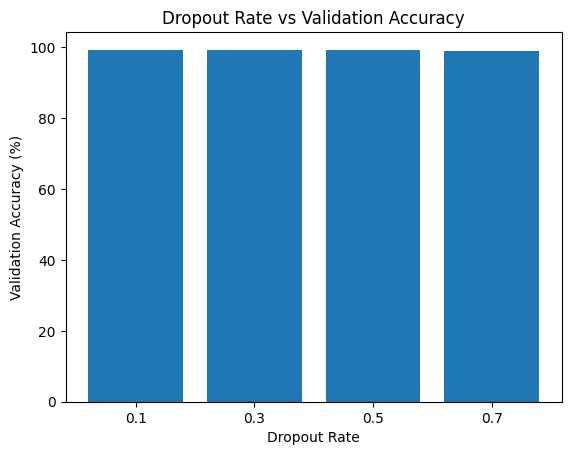

In [9]:
dropout_rates = [0.1, 0.3, 0.5, 0.7]
drop_results = {}

for rate in dropout_rates:
    print('\nTraining with Dropout =', rate)
    model = CNN_Dropout(rate).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    hist = {'val_acc': []}
    for epoch in range(5):
        train_epoch(model, train_loader, opt, criterion, device)
        acc = eval_model(model, test_loader, device)
        hist['val_acc'].append(acc)
        print(f"Epoch {epoch+1} Val Acc: {acc:.2f}%")
    drop_results[rate] = hist['val_acc'][-1]

print('\nDropout final validation accuracies:')
for r, a in drop_results.items():
    print(f"Dropout={r}: Val Acc={a:.2f}%")

plt.figure()
plt.bar([str(r) for r in drop_results.keys()], drop_results.values())
plt.title('Dropout Rate vs Validation Accuracy')
plt.xlabel('Dropout Rate')
plt.ylabel('Validation Accuracy (%)')
plt.show()

### Applying Batch Normalization on CNN

In [10]:
class CNN_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

# Train BN model
bn_model = CNN_BN().to(device)
bn_opt = optim.Adam(bn_model.parameters(), lr=1e-3)
bn_hist = {'val_acc': []}
for epoch in range(5):
    train_epoch(bn_model, train_loader, bn_opt, criterion, device)
    acc = eval_model(bn_model, test_loader, device)
    bn_hist['val_acc'].append(acc)
    print(f"BN Epoch {epoch+1} | Val Acc: {acc:.2f}%")

BN Epoch 1 | Val Acc: 98.43%
BN Epoch 2 | Val Acc: 97.47%
BN Epoch 3 | Val Acc: 98.56%
BN Epoch 4 | Val Acc: 98.88%
BN Epoch 5 | Val Acc: 99.09%


### Combining Batch Normalization with droupout

In [11]:
class CNN_BN_DROPOUT(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

combo = CNN_BN_DROPOUT(dropout_rate=0.5).to(device)
combo_opt = optim.Adam(combo.parameters(), lr=1e-3)
combo_hist = {'val_acc': []}
for epoch in range(5):
    train_epoch(combo, train_loader, combo_opt, criterion, device)
    acc = eval_model(combo, test_loader, device)
    combo_hist['val_acc'].append(acc)
    print(f"Combo Epoch {epoch+1} | Val Acc: {acc:.2f}%")

Combo Epoch 1 | Val Acc: 97.99%
Combo Epoch 2 | Val Acc: 98.57%
Combo Epoch 3 | Val Acc: 99.00%
Combo Epoch 4 | Val Acc: 98.84%
Combo Epoch 5 | Val Acc: 99.22%


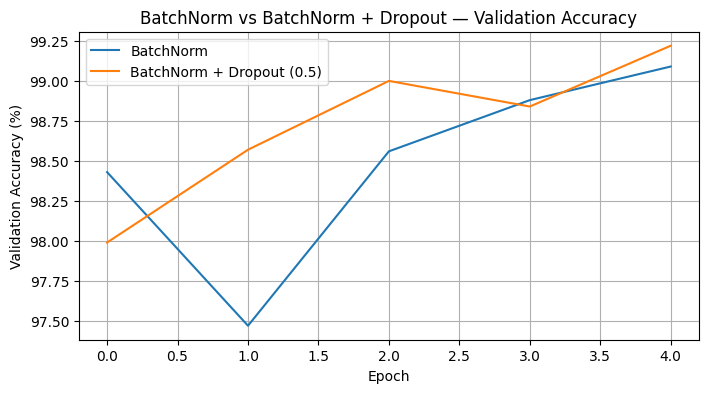

In [12]:
plt.figure(figsize=(8,4))
plt.plot(bn_hist['val_acc'], label='BatchNorm')
plt.plot(combo_hist['val_acc'], label='BatchNorm + Dropout (0.5)')
plt.title('BatchNorm vs BatchNorm + Dropout — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

# Analysis
## Importance of spatial feature learning
- Working on the image as an image not a normal vector so while using it we can relate each pixel with its neighbours.
- This allows us to generalize more better on images.
## Dropout effect
#### Why we use it
- The model can overfit on the training data if all the neurons worked so we use dropout with rates each rate correspond to the percentage of neurons that will sleep randomly, and if we use a high dropout the NN will not learn anything as many of the neurons will sleep so we use a value in the middle like 0.3 or 0.5.
## Batch Normalization
- Batch normalization is used before we pass the paramters to the next level of the neural network to normalize the data (or in our case `Batch`) to make the data's mean about 0 and the standard deviation about 1.
#### Then why we use it?
- Faster training.
- Better loss curve.
- Better convergence.
## Combination between dropout and batch normalization
- Combining Batch Normalization and Dropout can enhance both training stability and generalization.